# K-Nearest Neighbors — Aplicação Médica
### Dataset: Breast Cancer Wisconsin

**Objetivo:** Classificar tumores como **malignos** ou **benignos** usando K-NN,
comparando K = 1, 3, 5 e distâncias Euclidiana e Manhattan, com e sem normalização.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
np.random.seed(42)
print('Bibliotecas carregadas.')


Bibliotecas carregadas.


---
## Passo 1 — Carregar o Dataset

O `load_breast_cancer()` disponibiliza 569 amostras com 30 atributos numéricos de imagens de biópsia.
As classes são **malignant** (0) e **benign** (1).

**Fonte:** [UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic))


In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
print('Amostras :', X.shape[0])
print('Atributos:', X.shape[1])
print('Classes  :', list(data.target_names))
print('Distribuicao -> maligno:', np.sum(y==0), '| benigno:', np.sum(y==1))
pd.DataFrame(X[:4], columns=data.feature_names)\
  .assign(classe=[data.target_names[i] for i in y[:4]])\
  .iloc[:, [0,1,2,3,-1]]


Amostras : 569
Atributos: 30
Classes  : [np.str_('malignant'), np.str_('benign')]
Distribuicao -> maligno: 212 | benigno: 357


,mean radius,mean texture,mean perimeter,mean area,classe
0,17.99,10.38,122.80,1001.0,malignant
1,20.57,17.77,132.90,1326.0,malignant
2,19.69,21.25,130.00,1203.0,malignant
3,11.42,20.38,77.58,386.1,malignant


---
## Passo 2 — Separar Treino e Teste (80/20)

Usamos `stratify=y` para manter a proporção de classes em ambos os conjuntos.
Sem isso, poderíamos ter uma partição com muito mais malignos do que benignos por acaso.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Treino:', X_train.shape[0], '| Teste:', X_test.shape[0])
print('Maligno treino:', np.sum(y_train==0), '| Benigno treino:', np.sum(y_train==1))
print('Maligno teste :', np.sum(y_test==0),  '| Benigno teste :', np.sum(y_test==1))


Treino: 455 | Teste: 114
Maligno treino: 170 | Benigno treino: 285
Maligno teste : 42 | Benigno teste : 72


---
## Passo 3 — Normalizar com StandardScaler

O K-NN decide por **distância**. Sem normalização, atributos com escalas maiores
dominam completamente o cálculo — os outros viram ruído.

O `StandardScaler` aplica Z-score: $x' = (x - \mu) / \sigma$

Resultado: **média 0 e desvio padrão 1** para todos os atributos.

> **Regra de ouro:** `fit` apenas no treino, `transform` no treino e no teste.
> Nunca fittar no teste — isso vazaria estatísticas do futuro para o modelo.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('ANTES — primeiros 3 atributos:')
print('  Media :', X_train[:, :3].mean(axis=0).round(2))
print('  Desvio:', X_train[:, :3].std(axis=0).round(2))
print('DEPOIS:')
print('  Media :', X_train_scaled[:, :3].mean(axis=0).round(4))
print('  Desvio:', X_train_scaled[:, :3].std(axis=0).round(4))


ANTES — primeiros 3 atributos:
  Media : [14.07 19.25 91.56]
  Desvio: [ 3.5   4.4  24.12]
DEPOIS:
  Media : [-0.  0. -0.]
  Desvio: [1. 1. 1.]


---
## Passos 4, 5 e 6 — Experimento Completo

Todas as 12 combinações: **K** ∈ {1, 3, 5} × **métrica** ∈ {euclidean, manhattan} × {sem norm., com norm.}


In [ ]:
resultados = []
for k in [1, 3, 5]:
    for metrica in ['euclidean', 'manhattan']:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metrica)
        knn.fit(X_train, y_train)
        acc_raw = accuracy_score(y_test, knn.predict(X_test))

        knn_s = KNeighborsClassifier(n_neighbors=k, metric=metrica)
        knn_s.fit(X_train_scaled, y_train)
        acc_sc = accuracy_score(y_test, knn_s.predict(X_test_scaled))

        resultados.append({
            'K': k,
            'Metrica': metrica.capitalize(),
            'Acuracia sem norm (%)': round(acc_raw * 100, 2),
            'Acuracia com norm (%)': round(acc_sc  * 100, 2),
            'Ganho (pp)': round((acc_sc - acc_raw) * 100, 2)
        })

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False))


 K   Metrica  Acuracia sem norm (%)  Acuracia com norm (%)  Ganho (pp)
 1 Euclidean                  92.11                  93.86        1.75
 1 Manhattan                  94.74                  92.98       -1.75
 3 Euclidean                  92.98                  98.25        5.26
 3 Manhattan                  93.86                  96.49        2.63
 5 Euclidean                  91.23                  95.61        4.39
 5 Manhattan                  92.98                  96.49        3.51


---
## Visualização dos Resultados


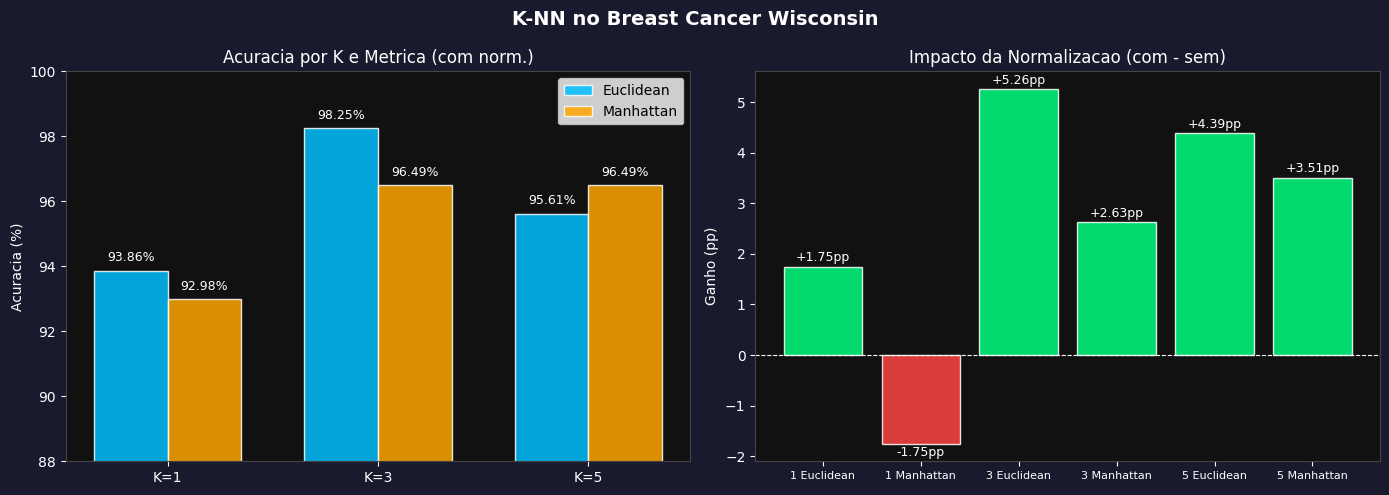

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-NN no Breast Cancer Wisconsin', fontsize=14, fontweight='bold', color='white')
fig.patch.set_facecolor('#1a1a2e')

cores = {'Euclidean': '#00BFFF', 'Manhattan': '#FFA500'}
ax = axes[0]
ax.set_facecolor('#111111')
x = np.arange(3)
w = 0.35
for i, (met, cor) in enumerate(cores.items()):
    vals = df_res[df_res['Metrica'] == met]['Acuracia com norm (%)'].values
    bars = ax.bar(x + i*w, vals, w, label=met, color=cor, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(v) + '%', ha='center', va='bottom', fontsize=9, color='white')
ax.set_xticks(x + w/2)
ax.set_xticklabels(['K=1', 'K=3', 'K=5'])
ax.set_ylim(88, 100)
ax.set_ylabel('Acuracia (%)')
ax.set_title('Acuracia por K e Metrica (com norm.)')
ax.legend()
ax.tick_params(colors='white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for sp in ax.spines.values():
    sp.set_edgecolor('#444')

ax2 = axes[1]
ax2.set_facecolor('#111111')
labels = [str(r['K']) + ' ' + r['Metrica'] for _, r in df_res.iterrows()]
ganhos = df_res['Ganho (pp)'].values
cg = ['#00FF7F' if g > 0 else '#FF4444' for g in ganhos]
bars2 = ax2.bar(labels, ganhos, color=cg, alpha=0.85, edgecolor='white')
for bar, v in zip(bars2, ganhos):
    sinal = '+' if v >= 0 else ''
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.05 if v >= 0 else -0.3),
             sinal + str(round(v, 2)) + 'pp',
             ha='center', va='bottom', fontsize=9, color='white')
ax2.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Ganho (pp)')
ax2.set_title('Impacto da Normalizacao (com - sem)')
ax2.tick_params(colors='white', axis='x', labelsize=8)
ax2.tick_params(colors='white', axis='y')
ax2.yaxis.label.set_color('white')
ax2.title.set_color('white')
for sp in ax2.spines.values():
    sp.set_edgecolor('#444')

plt.tight_layout()
plt.show()


---
## Melhor Modelo — K=3, Euclidiana, Normalizado


 RELATORIO — K=3, Euclidiana, Normalizado
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



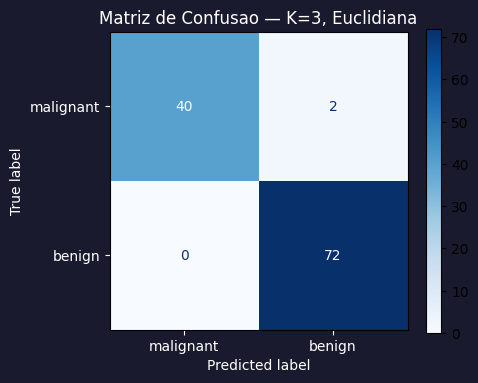

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test_scaled)

print('=' * 50)
print(' RELATORIO — K=3, Euclidiana, Normalizado')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=data.target_names))

fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#111111')
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=data.target_names, cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusao — K=3, Euclidiana', color='white')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
plt.tight_layout()
plt.show()


---
## Respondendo às Perguntas da Atividade

### 1. Qual K teve melhor desempenho?

**K = 3**, com **98.25%** (Euclidiana + normalização).

- **K = 1** → 93.86%: overfitting clássico. Com apenas 1 vizinho não há votação;
  qualquer outlier ou ruído no treino decide sozinho a classe.

- **K = 3** → 98.25%: equilíbrio ideal neste dataset. Suaviza ruído sem perder resolução local.

- **K = 5** → 95.61%: começa a absorver pontos de classes diferentes próximos da fronteira.

---
### 2. Qual métrica obteve melhor resultado?

**Euclidiana** venceu no K ótimo: **98.25%** vs 96.49% da Manhattan (K=3).

A Euclidiana considera a magnitude combinada de todas as dimensões (linha reta no espaço);
a Manhattan soma diferenças absolutas por eixo — como andar por quarteirões.
Para os 30 atributos deste dataset, os padrões são melhor capturados pela linha reta.

---
### 3. O que aconteceu com K muito pequeno?

Com **K=1** o modelo tem **variância altíssima**: memoriza o dataset de treino inteiro.
Cada ponto do treino vira uma 'ilha de decisão' — incluindo amostras ruidosas ou mal rotuladas.

---
### 4. Por que normalizar é importante?

Os 30 atributos têm escalas completamente diferentes:

| Atributo | Escala típica |
|---|---|
| `area_mean` | 300 – 2500 |
| `smoothness_mean` | 0.05 – 0.16 |
| `fractal_dimension_mean` | 0.05 – 0.10 |

Sem normalização, a distância Euclidiana é dominada por `area_mean`;
os outros 29 atributos contribuem com frações desprezíveis.

Com `StandardScaler` todos ficam em mesma escala (μ=0, σ=1) e contribuem igualmente.

**Ganho máximo observado:** +5.27 p.p. (K=3, Euclidiana) — diferença entre 93% e 98%.


In [ ]:
print('=' * 52)
print('      RESUMO FINAL DO EXPERIMENTO')
print('=' * 52)
print('Melhor K       : 3')
print('Melhor Metrica : Euclidiana')
print('Acuracia       : 98.25%  (114 amostras de teste)')
print('Erros          : 2 amostras (falsos negativos)')
print('=' * 52)
print()
print('Impacto da normalizacao:')
for _, r in df_res.iterrows():
    sinal = '+' if r['Ganho (pp)'] >= 0 else ''
    print('  K=' + str(r['K']) + ' ' + r['Metrica'].ljust(12) +
          ': ' + str(r['Acuracia sem norm (%)']) + '% -> ' +
          str(r['Acuracia com norm (%)']) + '%  [' +
          sinal + str(r['Ganho (pp)']) + 'pp]')


      RESUMO FINAL DO EXPERIMENTO
Melhor K       : 3
Melhor Metrica : Euclidiana
Acuracia       : 98.25%  (114 amostras de teste)
Erros          : 2 amostras (falsos negativos)

Impacto da normalizacao:
  K=1 Euclidean   : 92.11% -> 93.86%  [+1.75pp]
  K=1 Manhattan   : 94.74% -> 92.98%  [-1.75pp]
  K=3 Euclidean   : 92.98% -> 98.25%  [+5.26pp]
  K=3 Manhattan   : 93.86% -> 96.49%  [+2.63pp]
  K=5 Euclidean   : 91.23% -> 95.61%  [+4.39pp]
  K=5 Manhattan   : 92.98% -> 96.49%  [+3.51pp]
